In [2]:
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

DATA_ROOT = Path("/scratch/vserrano/cbc_pe_data/processed/bbh_32s_m1-xx_m2-xx_n100")

files = sorted(DATA_ROOT.glob("bbh_processed_32s_m1-*_m2-*_n100_*.h5"))

len(files), files[:3]

(20,
 [PosixPath('/scratch/vserrano/cbc_pe_data/processed/bbh_32s_m1-xx_m2-xx_n100/bbh_processed_32s_m1-20_m2-20_n100_01.h5'),
  PosixPath('/scratch/vserrano/cbc_pe_data/processed/bbh_32s_m1-xx_m2-xx_n100/bbh_processed_32s_m1-20_m2-20_n100_02.h5'),
  PosixPath('/scratch/vserrano/cbc_pe_data/processed/bbh_32s_m1-xx_m2-xx_n100/bbh_processed_32s_m1-20_m2-20_n100_03.h5')])

In [3]:
def parse_masses_from_name(path):
    pattern = r"m1-(\d+)_m2-(\d+)"
    match = re.search(pattern, path.name)

    if match is None:
        return None, None

    return float(match.group(1)), float(match.group(2))

In [4]:
rows = []

for path in files:
    expected_m1, expected_m2 = parse_masses_from_name(path)

    with h5py.File(path, "r") as f:
        X_shape = f["X"].shape
        y_shape = f["y"].shape

        m1 = f["parameters/mass_1"][:]
        m2 = f["parameters/mass_2"][:]
        spin1 = f["parameters/spin_1z"][:]
        spin2 = f["parameters/spin_2z"][:]
        chi_eff = f["parameters/chi_eff"][:]
        snr = f["snr/network"][:]
        distance = f["parameters/distance"][:]

        X_head = f["X"][:min(10, X_shape[0])]

        rows.append({
            "file": path.name,
            "path": str(path),
            "expected_m1": expected_m1,
            "expected_m2": expected_m2,
            "X_shape": X_shape,
            "y_shape": y_shape,

            "m1_min": float(m1.min()),
            "m1_max": float(m1.max()),
            "m2_min": float(m2.min()),
            "m2_max": float(m2.max()),

            "spin1_min": float(spin1.min()),
            "spin1_max": float(spin1.max()),
            "spin2_min": float(spin2.min()),
            "spin2_max": float(spin2.max()),
            "chi_eff_min": float(chi_eff.min()),
            "chi_eff_max": float(chi_eff.max()),

            "snr_min": float(snr.min()),
            "snr_max": float(snr.max()),
            "snr_mean": float(snr.mean()),
            "snr_std": float(snr.std()),

            "distance_min": float(distance.min()),
            "distance_max": float(distance.max()),
            "distance_mean": float(distance.mean()),

            "X_head_mean": float(X_head.mean()),
            "X_head_std": float(X_head.std()),
            "X_head_finite": bool(np.all(np.isfinite(X_head))),
        })

summary_df = pd.DataFrame(rows)
summary_df

,file,path,expected_m1,expected_m2,X_shape,y_shape,m1_min,m1_max,m2_min,m2_max,...,snr_min,snr_max,snr_mean,snr_std,distance_min,distance_max,distance_mean,X_head_mean,X_head_std,X_head_finite
0,bbh_processed_32s_m1-20_m2-20_n100_01.h5,/scratch/vserrano/cbc_pe_data/processed/bbh_32...,20.0,20.0,"(100, 3, 131072)","(100, 3)",20.0,20.0,20.0,20.0,...,10.115083,24.961651,17.124666,4.514588,267.904755,3276.833740,983.756714,-0.000144,21.828789,True
1,bbh_processed_32s_m1-20_m2-20_n100_02.h5,/scratch/vserrano/cbc_pe_data/processed/bbh_32...,20.0,20.0,"(100, 3, 131072)","(100, 3)",20.0,20.0,20.0,20.0,...,10.323012,24.966770,17.620884,4.432623,210.147781,2396.660156,962.349060,0.000725,21.854034,True
2,bbh_processed_32s_m1-20_m2-20_n100_03.h5,/scratch/vserrano/cbc_pe_data/processed/bbh_32...,20.0,20.0,"(100, 3, 131072)","(100, 3)",20.0,20.0,20.0,20.0,...,10.003835,24.554033,17.347824,4.474446,202.552826,2901.284424,969.845764,0.000206,21.818184,True
3,bbh_processed_32s_m1-20_m2-20_n100_04.h5,/scratch/vserrano/cbc_pe_data/processed/bbh_32...,20.0,20.0,"(100, 3, 131072)","(100, 3)",20.0,20.0,20.0,20.0,...,10.002517,24.978949,17.324078,4.375668,54.308338,2707.672607,1006.876709,-0.000420,21.813980,True
4,bbh_processed_32s_m1-20_m2-20_n100_05.h5,/scratch/vserrano/cbc_pe_data/processed/bbh_32...,20.0,20.0,"(100, 3, 131072)","(100, 3)",20.0,20.0,20.0,20.0,...,10.012852,24.919485,17.327120,4.357930,184.740860,2955.750000,958.127258,0.000125,21.848938,True
5,bbh_processed_32s_m1-40_m2-40_n100_01.h5,/scratch/vserrano/cbc_pe_data/processed/bbh_32...,40.0,40.0,"(100, 3, 131072)","(100, 3)",40.0,40.0,40.0,40.0,...,10.172884,24.855940,16.564140,4.351919,391.752838,5078.010254,1788.528564,0.000034,21.823973,True
6,bbh_processed_32s_m1-40_m2-40_n100_02.h5,/scratch/vserrano/cbc_pe_data/processed/bbh_32...,40.0,40.0,"(100, 3, 131072)","(100, 3)",40.0,40.0,40.0,40.0,...,10.008679,24.984766,17.210049,4.521517,221.151062,4680.343262,1705.697388,0.000021,21.828552,True
7,bbh_processed_32s_m1-40_m2-40_n100_03.h5,/scratch/vserrano/cbc_pe_data/processed/bbh_32...,40.0,40.0,"(100, 3, 131072)","(100, 3)",40.0,40.0,40.0,40.0,...,10.081676,24.896725,17.002567,4.579386,316.990845,4188.227539,1742.013550,0.000149,21.795027,True
8,bbh_processed_32s_m1-40_m2-40_n100_04.h5,/scratch/vserrano/cbc_pe_data/processed/bbh_32...,40.0,40.0,"(100, 3, 131072)","(100, 3)",40.0,40.0,40.0,40.0,...,10.036507,24.857874,17.104450,4.297521,361.494019,4757.863281,1689.859009,0.000290,21.809931,True
9,bbh_processed_32s_m1-40_m2-40_n100_05.h5,/scratch/vserrano/cbc_pe_data/processed/bbh_32...,40.0,40.0,"(100, 3, 131072)","(100, 3)",40.0,40.0,40.0,40.0,...,10.055966,24.887585,16.221348,4.512819,403.007111,4257.209961,1866.573730,0.000202,21.815426,True


In [5]:
summary_df["mass_1_ok"] = (
    np.isclose(summary_df["m1_min"], summary_df["expected_m1"])
    & np.isclose(summary_df["m1_max"], summary_df["expected_m1"])
)

summary_df["mass_2_ok"] = (
    np.isclose(summary_df["m2_min"], summary_df["expected_m2"])
    & np.isclose(summary_df["m2_max"], summary_df["expected_m2"])
)

summary_df["spins_zero_ok"] = (
    np.isclose(summary_df["spin1_min"], 0.0)
    & np.isclose(summary_df["spin1_max"], 0.0)
    & np.isclose(summary_df["spin2_min"], 0.0)
    & np.isclose(summary_df["spin2_max"], 0.0)
)

summary_df["chi_eff_zero_ok"] = (
    np.isclose(summary_df["chi_eff_min"], 0.0)
    & np.isclose(summary_df["chi_eff_max"], 0.0)
)

summary_df["snr_ok"] = (
    (summary_df["snr_min"] >= 10.0)
    & (summary_df["snr_max"] <= 25.0)
)

summary_df["shape_ok"] = summary_df["X_shape"].apply(
    lambda s: s == (100, 3, 131072)
)

summary_df["finite_ok"] = summary_df["X_head_finite"]

check_cols = [
    "file",
    "mass_1_ok",
    "mass_2_ok",
    "spins_zero_ok",
    "chi_eff_zero_ok",
    "snr_ok",
    "shape_ok",
    "finite_ok",
]

summary_df[check_cols]

,file,mass_1_ok,mass_2_ok,spins_zero_ok,chi_eff_zero_ok,snr_ok,shape_ok,finite_ok
0,bbh_processed_32s_m1-20_m2-20_n100_01.h5,True,True,True,True,True,True,True
1,bbh_processed_32s_m1-20_m2-20_n100_02.h5,True,True,True,True,True,True,True
2,bbh_processed_32s_m1-20_m2-20_n100_03.h5,True,True,True,True,True,True,True
3,bbh_processed_32s_m1-20_m2-20_n100_04.h5,True,True,True,True,True,True,True
4,bbh_processed_32s_m1-20_m2-20_n100_05.h5,True,True,True,True,True,True,True
5,bbh_processed_32s_m1-40_m2-40_n100_01.h5,True,True,True,True,True,True,True
6,bbh_processed_32s_m1-40_m2-40_n100_02.h5,True,True,True,True,True,True,True
7,bbh_processed_32s_m1-40_m2-40_n100_03.h5,True,True,True,True,True,True,True
8,bbh_processed_32s_m1-40_m2-40_n100_04.h5,True,True,True,True,True,True,True
9,bbh_processed_32s_m1-40_m2-40_n100_05.h5,True,True,True,True,True,True,True


In [6]:
for col in check_cols[1:]:
    print(col, ":", summary_df[col].sum(), "/", len(summary_df))

mass_1_ok : 20 / 20
mass_2_ok : 20 / 20
spins_zero_ok : 20 / 20
chi_eff_zero_ok : 20 / 20
snr_ok : 20 / 20
shape_ok : 20 / 20
finite_ok : 20 / 20


In [7]:
summary_df.groupby("expected_m1")[["snr_mean", "snr_std", "distance_mean"]].describe()

snr_mean                                                        \
               count       mean       std        min        25%        50%   
expected_m1                                                                  
20.0             5.0  17.348914  0.177022  17.124666  17.324078  17.327120   
40.0             5.0  16.820511  0.415400  16.221348  16.564140  17.002567   
60.0             5.0  16.538723  0.118882  16.392010  16.509758  16.514330   
80.0             5.0  16.933238  0.554682  16.285263  16.368990  17.296196   

                                  snr_std            ...                      \
                   75%        max   count      mean  ...       75%       max   
expected_m1                                          ...                       
20.0         17.347824  17.620884     5.0  4.431051  ...  4.474446  4.514588   
40.0         17.104450  17.210049     5.0  4.452632  ...  4.521517  4.579386   
60.0         16.556423  16.721094     5.0  4.329402  ...  4.395887  4.601614   
80.0         17.351616  17.364124     5.0  4.172843  ...  4.246897  4.501451   

            distance_mean                                                     \
                    count         mean         std          min          25%   
expected_m1                                                                    
20.0                  5.0   976.191101   19.729501   958.127258   962.349060   
40.0                  5.0  1758.534448   71.332224  1689.859009  1705.697388   
60.0                  5.0  2368.499414   66.821411  2273.255371  2349.552734   
80.0                  5.0  2943.865771  135.004293  2788.995850  2817.085205   

                                                    
                     50%          75%          max  
expected_m1                                         
20.0          969.845764   983.756714  1006.876709  
40.0         1742.013550  1788.528564  1866.573730  
60.0         2363.541016  2402.508789  2453.639160  
80.0         2993.474365  3018.270020  3101.503418  

[4 rows x 24 columns]

In [8]:
summary_df.groupby("expected_m1")[["snr_mean", "snr_std", "distance_mean"]].describe()

snr_mean                                                        \
               count       mean       std        min        25%        50%   
expected_m1                                                                  
20.0             5.0  17.348914  0.177022  17.124666  17.324078  17.327120   
40.0             5.0  16.820511  0.415400  16.221348  16.564140  17.002567   
60.0             5.0  16.538723  0.118882  16.392010  16.509758  16.514330   
80.0             5.0  16.933238  0.554682  16.285263  16.368990  17.296196   

                                  snr_std            ...                      \
                   75%        max   count      mean  ...       75%       max   
expected_m1                                          ...                       
20.0         17.347824  17.620884     5.0  4.431051  ...  4.474446  4.514588   
40.0         17.104450  17.210049     5.0  4.452632  ...  4.521517  4.579386   
60.0         16.556423  16.721094     5.0  4.329402  ...  4.395887  4.601614   
80.0         17.351616  17.364124     5.0  4.172843  ...  4.246897  4.501451   

            distance_mean                                                     \
                    count         mean         std          min          25%   
expected_m1                                                                    
20.0                  5.0   976.191101   19.729501   958.127258   962.349060   
40.0                  5.0  1758.534448   71.332224  1689.859009  1705.697388   
60.0                  5.0  2368.499414   66.821411  2273.255371  2349.552734   
80.0                  5.0  2943.865771  135.004293  2788.995850  2817.085205   

                                                    
                     50%          75%          max  
expected_m1                                         
20.0          969.845764   983.756714  1006.876709  
40.0         1742.013550  1788.528564  1866.573730  
60.0         2363.541016  2402.508789  2453.639160  
80.0         2993.474365  3018.270020  3101.503418  

[4 rows x 24 columns]

In [9]:
sample_rows = []

for path in files:
    expected_m1, expected_m2 = parse_masses_from_name(path)

    with h5py.File(path, "r") as f:
        snr = f["snr/network"][:]
        distance = f["parameters/distance"][:]
        chirp_mass = f["parameters/chirp_mass"][:]
        total_mass = f["parameters/total_mass"][:]

        for i in range(len(snr)):
            sample_rows.append({
                "file": path.name,
                "mass_group": expected_m1,
                "sample_index": i,
                "snr": snr[i],
                "distance": distance[i],
                "chirp_mass": chirp_mass[i],
                "total_mass": total_mass[i],
            })

samples_df = pd.DataFrame(sample_rows)
samples_df.head()

,file,mass_group,sample_index,snr,distance,chirp_mass,total_mass
0,bbh_processed_32s_m1-20_m2-20_n100_01.h5,20.0,0,11.580751,1478.337891,17.411011,40.0
1,bbh_processed_32s_m1-20_m2-20_n100_01.h5,20.0,1,20.430492,386.724854,17.411011,40.0
2,bbh_processed_32s_m1-20_m2-20_n100_01.h5,20.0,2,12.424130,1501.790405,17.411011,40.0
3,bbh_processed_32s_m1-20_m2-20_n100_01.h5,20.0,3,10.551773,1427.217651,17.411011,40.0
4,bbh_processed_32s_m1-20_m2-20_n100_01.h5,20.0,4,11.502481,1378.674805,17.411011,40.0


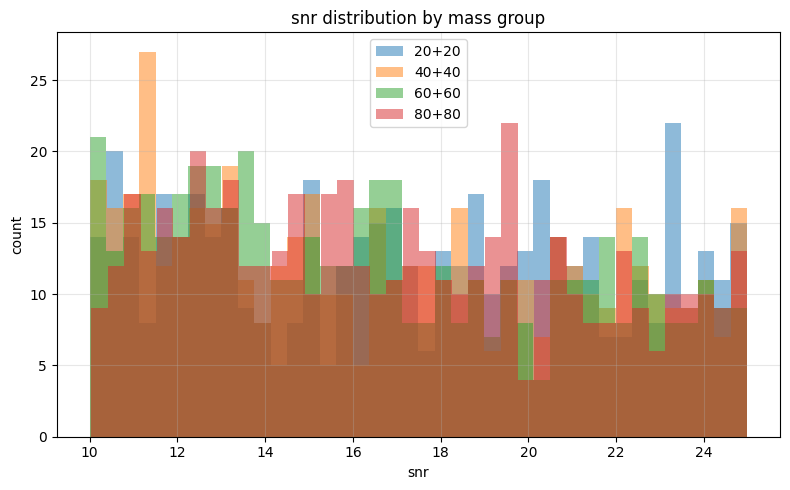

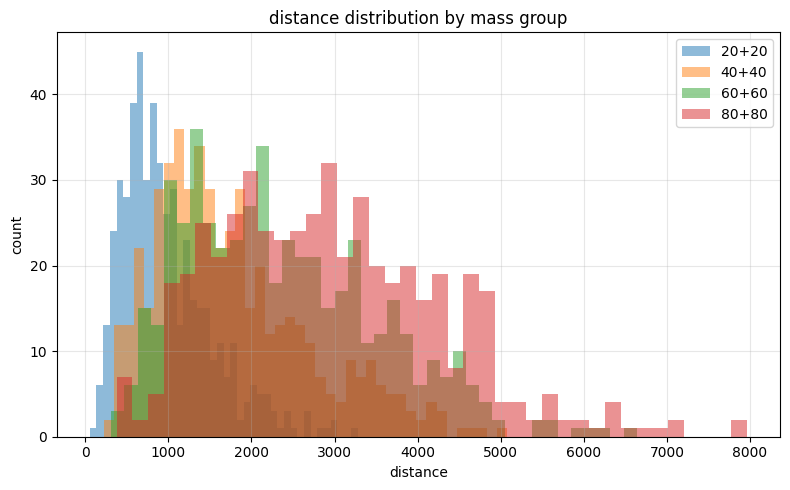

In [10]:
for col in ["snr", "distance"]:
    plt.figure(figsize=(8, 5))

    for mass_group, group in samples_df.groupby("mass_group"):
        plt.hist(group[col], bins=40, alpha=0.5, label=f"{mass_group:.0f}+{mass_group:.0f}")

    plt.xlabel(col)
    plt.ylabel("count")
    plt.title(f"{col} distribution by mass group")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [11]:
x_rows = []

for path in files:
    expected_m1, expected_m2 = parse_masses_from_name(path)

    with h5py.File(path, "r") as f:
        X = f["X"][:]

    x_mean = X.mean(axis=(1, 2))
    x_std = X.std(axis=(1, 2))
    x_rms = np.sqrt(np.mean(X**2, axis=(1, 2)))
    x_max_abs = np.max(np.abs(X), axis=(1, 2))

    for i in range(X.shape[0]):
        x_rows.append({
            "file": path.name,
            "mass_group": expected_m1,
            "sample_index": i,
            "x_mean": x_mean[i],
            "x_std": x_std[i],
            "x_rms": x_rms[i],
            "x_max_abs": x_max_abs[i],
        })

x_df = pd.DataFrame(x_rows)
x_df.head()

,file,mass_group,sample_index,x_mean,x_std,x_rms,x_max_abs
0,bbh_processed_32s_m1-20_m2-20_n100_01.h5,20.0,0,-0.001651,21.873533,21.873533,106.745346
1,bbh_processed_32s_m1-20_m2-20_n100_01.h5,20.0,1,0.000686,21.831364,21.831364,132.460495
2,bbh_processed_32s_m1-20_m2-20_n100_01.h5,20.0,2,0.000183,21.713478,21.713478,106.568443
3,bbh_processed_32s_m1-20_m2-20_n100_01.h5,20.0,3,-0.000134,21.836889,21.836889,119.179169
4,bbh_processed_32s_m1-20_m2-20_n100_01.h5,20.0,4,0.000218,21.838703,21.838703,106.837585


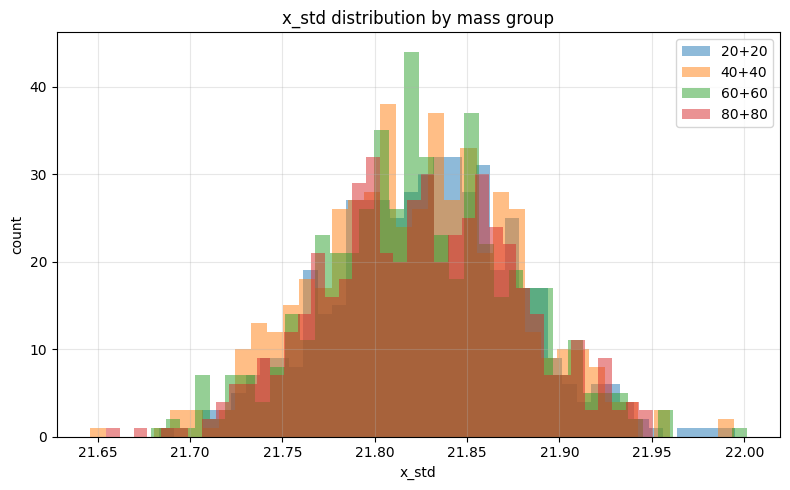

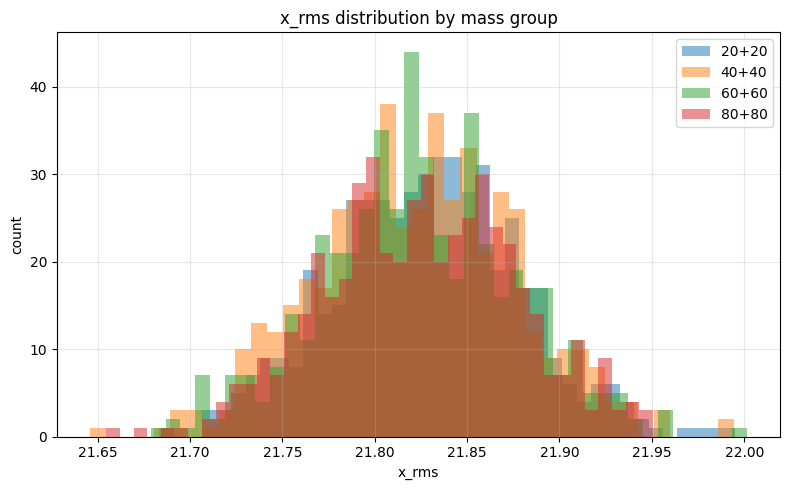

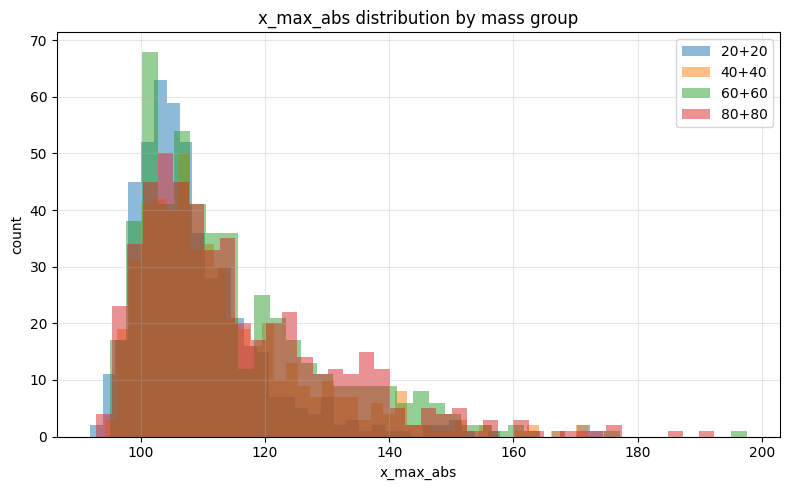

In [12]:
for col in ["x_std", "x_rms", "x_max_abs"]:
    plt.figure(figsize=(8, 5))

    for mass_group, group in x_df.groupby("mass_group"):
        plt.hist(group[col], bins=40, alpha=0.5, label=f"{mass_group:.0f}+{mass_group:.0f}")

    plt.xlabel(col)
    plt.ylabel("count")
    plt.title(f"{col} distribution by mass group")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [14]:
clf_df = x_df.merge(
    samples_df[["file", "sample_index", "snr", "distance"]],
    on=["file", "sample_index"],
    how="left",
)

features = clf_df[["x_mean", "x_std", "x_rms", "x_max_abs", "snr"]].to_numpy()
labels = clf_df["mass_group"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.25,
    random_state=123,
    stratify=labels,
)

clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, multi_class="auto"),
)

clf.fit(X_train, y_train)

pred = clf.predict(X_test)

print("accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

/afs/ciemat.es/user/v/vserrano/miniconda3/envs/gw-env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


accuracy: 0.284
              precision    recall  f1-score   support

        20.0       0.33      0.49      0.39       125
        40.0       0.22      0.14      0.17       125
        60.0       0.25      0.22      0.24       125
        80.0       0.29      0.29      0.29       125

    accuracy                           0.28       500
   macro avg       0.27      0.28      0.27       500
weighted avg       0.27      0.28      0.27       500

[[61 18 24 22]
 [52 17 29 27]
 [36 22 28 39]
 [37 21 31 36]]


In [15]:
features_no_snr = clf_df[["x_mean", "x_std", "x_rms", "x_max_abs"]].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    features_no_snr,
    labels,
    test_size=0.25,
    random_state=123,
    stratify=labels,
)

clf_no_snr = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000),
)

clf_no_snr.fit(X_train, y_train)
pred = clf_no_snr.predict(X_test)

print("accuracy without SNR:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

accuracy without SNR: 0.3
              precision    recall  f1-score   support

        20.0       0.32      0.55      0.40       125
        40.0       0.25      0.19      0.22       125
        60.0       0.32      0.11      0.17       125
        80.0       0.30      0.34      0.32       125

    accuracy                           0.30       500
   macro avg       0.30      0.30      0.28       500
weighted avg       0.30      0.30      0.28       500

[[69 21  9 26]
 [59 24 12 30]
 [40 27 14 44]
 [49 24  9 43]]


In [16]:
unique_files = clf_df[["file", "mass_group"]].drop_duplicates()

train_files = []
test_files = []

rng = np.random.default_rng(123)

for mass_group, group in unique_files.groupby("mass_group"):
    files_group = group["file"].to_numpy()
    rng.shuffle(files_group)

    test_files.extend(files_group[:1])
    train_files.extend(files_group[1:])

train_files = set(train_files)
test_files = set(test_files)

train_mask = clf_df["file"].isin(train_files)
test_mask = clf_df["file"].isin(test_files)

X_train = clf_df.loc[train_mask, ["x_mean", "x_std", "x_rms", "x_max_abs"]].to_numpy()
y_train = clf_df.loc[train_mask, "mass_group"].to_numpy()

X_test = clf_df.loc[test_mask, ["x_mean", "x_std", "x_rms", "x_max_abs"]].to_numpy()
y_test = clf_df.loc[test_mask, "mass_group"].to_numpy()

clf_file_split = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000),
)

clf_file_split.fit(X_train, y_train)
pred = clf_file_split.predict(X_test)

print("Train files:", sorted(train_files))
print("Test files:", sorted(test_files))
print("accuracy file split:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

Train files: ['bbh_processed_32s_m1-20_m2-20_n100_01.h5', 'bbh_processed_32s_m1-20_m2-20_n100_02.h5', 'bbh_processed_32s_m1-20_m2-20_n100_03.h5', 'bbh_processed_32s_m1-20_m2-20_n100_04.h5', 'bbh_processed_32s_m1-40_m2-40_n100_01.h5', 'bbh_processed_32s_m1-40_m2-40_n100_02.h5', 'bbh_processed_32s_m1-40_m2-40_n100_03.h5', 'bbh_processed_32s_m1-40_m2-40_n100_05.h5', 'bbh_processed_32s_m1-60_m2-60_n100_01.h5', 'bbh_processed_32s_m1-60_m2-60_n100_02.h5', 'bbh_processed_32s_m1-60_m2-60_n100_03.h5', 'bbh_processed_32s_m1-60_m2-60_n100_04.h5', 'bbh_processed_32s_m1-80_m2-80_n100_01.h5', 'bbh_processed_32s_m1-80_m2-80_n100_02.h5', 'bbh_processed_32s_m1-80_m2-80_n100_03.h5', 'bbh_processed_32s_m1-80_m2-80_n100_04.h5']
Test files: ['bbh_processed_32s_m1-20_m2-20_n100_05.h5', 'bbh_processed_32s_m1-40_m2-40_n100_04.h5', 'bbh_processed_32s_m1-60_m2-60_n100_05.h5', 'bbh_processed_32s_m1-80_m2-80_n100_05.h5']
accuracy file split: 0.295
              precision    recall  f1-score   support

        20.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [18]:
X_rows = []
y_rows = []
file_rows = []

stride = 64  # 131072 / 64 = 2048 samples per detector

for path in files:
    expected_m1, expected_m2 = parse_masses_from_name(path)

    with h5py.File(path, "r") as f:
        X = f["X"][:, :, ::stride]  # (100, 3, 2048)

    X_flat = X.reshape(X.shape[0], -1)

    X_rows.append(X_flat)
    y_rows.extend([expected_m1] * X.shape[0])
    file_rows.extend([path.name] * X.shape[0])

X_down = np.concatenate(X_rows, axis=0)
y_mass = np.asarray(y_rows)
file_arr = np.asarray(file_rows)

print("X_down:", X_down.shape)
print("y_mass:", y_mass.shape)

X_down: (2000, 6144)
y_mass: (2000,)


In [19]:
unique_files = pd.DataFrame({
    "file": file_arr,
    "mass_group": y_mass,
}).drop_duplicates()

train_files = []
test_files = []

rng = np.random.default_rng(123)

for mass_group, group in unique_files.groupby("mass_group"):
    fg = group["file"].to_numpy()
    rng.shuffle(fg)
    test_files.extend(fg[:1])
    train_files.extend(fg[1:])

train_mask = np.isin(file_arr, train_files)
test_mask = np.isin(file_arr, test_files)

X_train = X_down[train_mask]
X_test = X_down[test_mask]
y_train = y_mass[train_mask]
y_test = y_mass[test_mask]

clf_raw = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=3000, C=1.0),
)

clf_raw.fit(X_train, y_train)
pred = clf_raw.predict(X_test)

print("accuracy downsampled raw X:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

accuracy downsampled raw X: 0.26
              precision    recall  f1-score   support

        20.0       0.27      0.26      0.26       100
        40.0       0.25      0.25      0.25       100
        60.0       0.27      0.21      0.24       100
        80.0       0.26      0.32      0.29       100

    accuracy                           0.26       400
   macro avg       0.26      0.26      0.26       400
weighted avg       0.26      0.26      0.26       400

[[26 28 18 28]
 [27 25 16 32]
 [22 26 21 31]
 [23 22 23 32]]


In [20]:
def windowed_rms_features(X, n_windows=64):
    """
    X shape: (n_samples, n_detectors, n_time)
    returns shape: (n_samples, n_detectors * n_windows)
    """
    n, c, t = X.shape
    usable = (t // n_windows) * n_windows
    X = X[:, :, :usable]
    Xw = X.reshape(n, c, n_windows, usable // n_windows)
    rms = np.sqrt(np.mean(Xw**2, axis=-1))
    return rms.reshape(n, c * n_windows)

In [21]:
X_feat_rows = []
y_rows = []
file_rows = []

for path in files:
    expected_m1, expected_m2 = parse_masses_from_name(path)

    with h5py.File(path, "r") as f:
        X = f["X"][:]

    feat = windowed_rms_features(X, n_windows=64)

    X_feat_rows.append(feat)
    y_rows.extend([expected_m1] * X.shape[0])
    file_rows.extend([path.name] * X.shape[0])

X_winrms = np.concatenate(X_feat_rows, axis=0)
y_mass = np.asarray(y_rows)
file_arr = np.asarray(file_rows)

print(X_winrms.shape)

(2000, 192)


In [24]:
unique_files = pd.DataFrame({
    "file": file_arr,
    "mass_group": y_mass,
}).drop_duplicates()

train_files = []
test_files = []

rng = np.random.default_rng(123)

for mass_group, group in unique_files.groupby("mass_group"):
    fg = group["file"].to_numpy()
    rng.shuffle(fg)
    test_files.extend(fg[:1])
    train_files.extend(fg[1:])

train_mask = np.isin(file_arr, train_files)
test_mask = np.isin(file_arr, test_files)

X_train = X_winrms[train_mask]
X_test = X_winrms[test_mask]
y_train = y_mass[train_mask]
y_test = y_mass[test_mask]

clf_winrms = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=3000, C=1.0),
)

clf_winrms.fit(X_train, y_train)
pred = clf_winrms.predict(X_test)

print("accuracy windowed RMS features:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

accuracy windowed RMS features: 0.265
              precision    recall  f1-score   support

        20.0       0.24      0.25      0.25       100
        40.0       0.23      0.22      0.23       100
        60.0       0.29      0.32      0.30       100
        80.0       0.30      0.27      0.28       100

    accuracy                           0.27       400
   macro avg       0.26      0.27      0.26       400
weighted avg       0.26      0.27      0.26       400

[[25 25 28 22]
 [24 22 31 23]
 [27 22 32 19]
 [27 26 20 27]]


In [22]:
def plot_spectrogram_sample(path, sample_idx=0, detector_idx=0):
    with h5py.File(path, "r") as f:
        x = f["X"][sample_idx, detector_idx]
        fs = float(f.attrs["sampling_frequency"])

    plt.figure(figsize=(10, 5))
    plt.specgram(x, NFFT=1024, Fs=fs, noverlap=768)
    plt.ylim(0, 512)
    plt.xlabel("Time [s]")
    plt.ylabel("Frequency [Hz]")
    plt.title(f"{path.name} | sample {sample_idx} | detector {detector_idx}")
    plt.colorbar(label="Power")
    plt.tight_layout()
    plt.show()

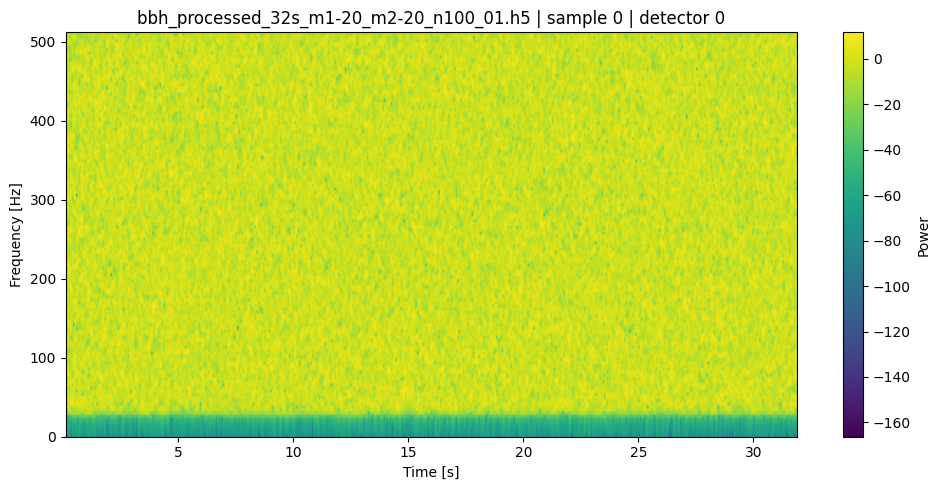

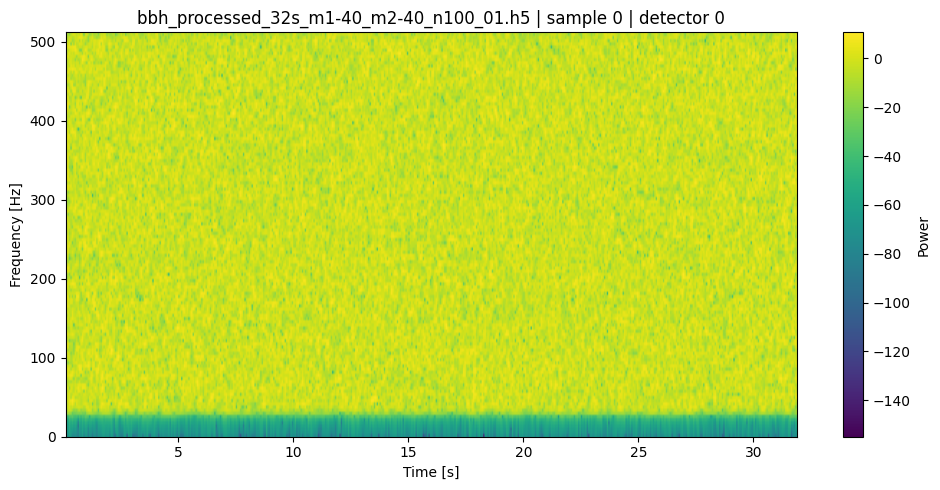

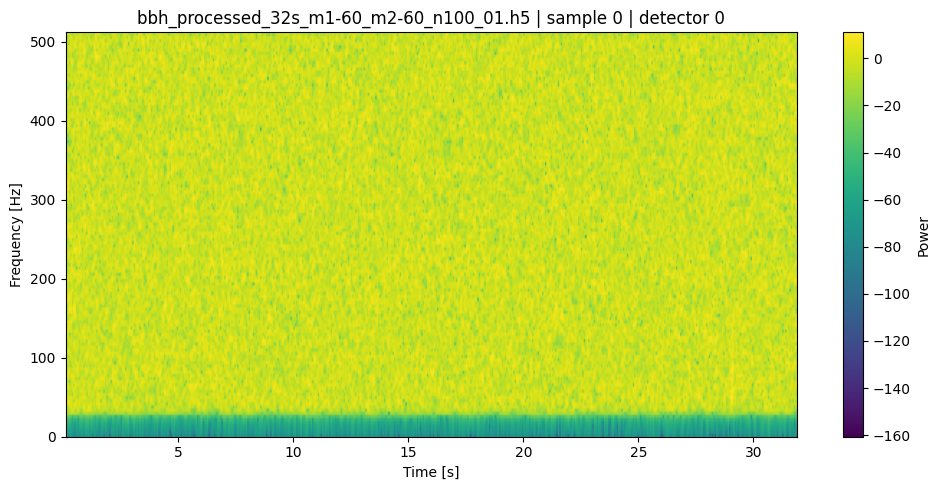

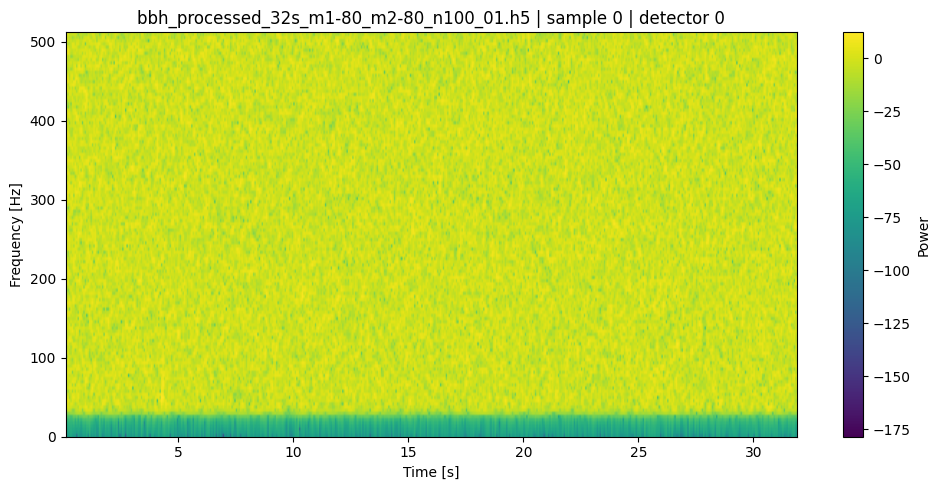

In [23]:
for mass in [20, 40, 60, 80]:
    path = [p for p in files if f"m1-{mass}_m2-{mass}" in p.name][0]
    plot_spectrogram_sample(path, sample_idx=0, detector_idx=0)